In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
path = "../Data/raw"

csv_files = glob.glob(os.path.join(path, "*.csv"))

df = pd.concat(
    [pd.read_csv(file, low_memory=False) for file in csv_files],
    ignore_index=True
)

df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [3]:
print("Shape:", df.shape)

df.info()

df.describe().T

Shape: (2830743, 79)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   

c:\Network Intrusion Detection System\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Network Intrusion Detection System\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.0,31316.0,3204828.5,119999998.0
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.0,2.0,4.0,291922.0
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.0,62.0,187.0,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2830743.0,5.829582e+04,5.770923e+05,0.0,0.0,0.0,0.0,110000000.0
Idle Mean,2830743.0,8.316037e+06,2.363008e+07,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2830743.0,5.038439e+05,4.602984e+06,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2830743.0,8.695752e+06,2.436689e+07,0.0,0.0,0.0,0.0,120000000.0


In [4]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

Flow Bytes/s    1358
dtype: int64

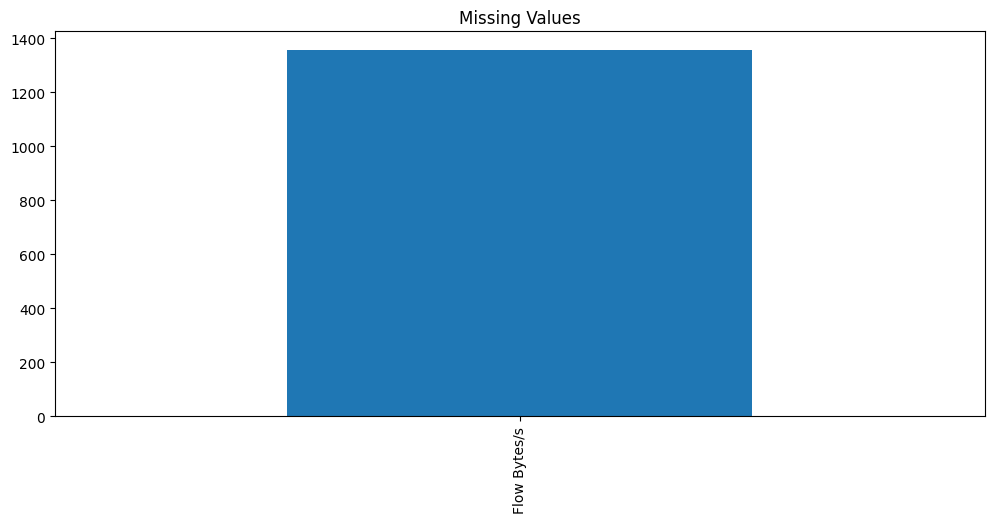

In [5]:
missing[missing > 0].plot.bar(figsize=(12,5))

plt.title("Missing Values")
plt.show()

In [6]:
df.columns = df.columns.str.strip()

In [7]:
print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [8]:
(df["Flow Duration"] < 0).sum()

np.int64(115)

In [9]:
df = df.drop(df[df["Flow Duration"] < 0].index)

In [10]:
print("Negative Flow Duration:", (df["Flow Duration"] < 0).sum())

df = df[df["Flow Duration"] >= 0]

Negative Flow Duration: 0


In [11]:
import numpy as np

print("Infinite Values:", np.isinf(df.select_dtypes(include=np.number)).sum().sum())

df.replace([np.inf, -np.inf], np.nan, inplace=True)

Infinite Values: 4376


In [12]:
# Replace infinities with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Check missing values after replacement
print("Missing Values:", df.isnull().sum().sum())

# Remove rows containing NaN
df.dropna(inplace=True)

# Verify
print("Remaining Missing Values:", df.isnull().sum().sum())

# Verify no infinite values remain
print("Remaining Infinite Values:",
      np.isinf(df.select_dtypes(include=np.number)).sum().sum())

Missing Values: 5734
Remaining Missing Values: 0
Remaining Infinite Values: 0


In [13]:
print("Shape Before:", df.shape)

df.drop_duplicates(inplace=True)

print("Shape After:", df.shape)

Shape Before: (2827761, 79)
Shape After: (2520691, 79)


In [14]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [15]:
df["Label"] = (
    df["Label"]
    .str.replace(r"Web Attack.*Brute Force", "Web Attack - Brute Force", regex=True)
    .str.replace(r"Web Attack.*XSS", "Web Attack - XSS", regex=True)
    .str.replace(r"Web Attack.*Sql Injection", "Web Attack - Sql Injection", regex=True)
)

In [16]:
print(df["Label"].value_counts())

Label
BENIGN                        2094950
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack - Brute Force         1470
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [17]:
attack_percentage = (
    df["Label"].value_counts(normalize=True) * 100
).round(2)

print(attack_percentage)

Label
BENIGN                        83.11
DoS Hulk                       6.86
DDoS                           5.08
PortScan                       3.60
DoS GoldenEye                  0.41
FTP-Patator                    0.24
DoS slowloris                  0.21
DoS Slowhttptest               0.21
SSH-Patator                    0.13
Bot                            0.08
Web Attack - Brute Force       0.06
Web Attack - XSS               0.03
Infiltration                   0.00
Web Attack - Sql Injection     0.00
Heartbleed                     0.00
Name: proportion, dtype: float64


In [18]:
import os

os.makedirs("../Data/processed", exist_ok=True)

df.to_csv(
    "../Data/processed/network_intrusion_processed.csv",
    index=False
)

print("Saved Successfully!")

Saved Successfully!


In [19]:
import pandas as pd

df = pd.read_csv("../Data/processed/network_intrusion_processed.csv")

sample_size = {
    "BENIGN": 100000,
    "DoS Hulk": 30000,
    "DDoS": 30000,
    "PortScan": 25000,
    "DoS GoldenEye": 10000,
    "FTP-Patator": 5000,
    "DoS slowloris": 5000,
    "DoS Slowhttptest": 5000,
    "SSH-Patator": 3000,
    "Bot": 2000,
    "Web Attack - Brute Force": 1470,
    "Web Attack - XSS": 652,
    "Web Attack - Sql Injection": 21,
    "Infiltration": 36,
    "Heartbleed": 11
}

small_df = pd.concat([
    df[df["Label"] == attack].sample(
        n=min(size, len(df[df["Label"] == attack])),
        random_state=42
    )
    for attack, size in sample_size.items()
])

small_df = small_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(small_df.shape)

small_df.to_csv(
    "../Data/processed/network_intrusion_small.csv",
    index=False
)

(217138, 79)


In [20]:
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from xgboost import XGBClassifier

In [21]:
import pandas as pd

df = pd.read_csv("../Data/processed/network_intrusion_small.csv")

print(df.shape)
df.head()

(217138, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,98624356,5,7,319,11595,307,0,63.800000,135.986029,...,20,13001.0,0.00,13001,13001,98600000.0,0.0,98600000,98600000,DoS Hulk
1,80,72601514,8,6,56,11601,20,0,7.000000,5.656854,...,20,1005.0,0.00,1005,1005,36100000.0,37900000.0,62900000,9305753,DDoS
2,80,103629712,15,3,2390,6,239,0,159.333333,115.482631,...,32,3703491.0,5236718.27,7406410,572,19200000.0,18800000.0,51300000,5962108,DoS slowloris
3,80,13951,2,1,12,0,6,6,6.000000,0.000000,...,20,0.0,0.00,0,0,0.0,0.0,0,0,DoS Hulk
4,443,61,2,0,0,0,0,0,0.000000,0.000000,...,32,0.0,0.00,0,0,0.0,0.0,0,0,BENIGN


In [22]:
X = df.drop("Label", axis=1)
y = df["Label"]

In [34]:
df["Label"].value_counts()

Label
BENIGN                        100000
DDoS                           30000
DoS Hulk                       30000
PortScan                       25000
DoS GoldenEye                  10000
DoS slowloris                   5000
FTP-Patator                     5000
DoS Slowhttptest                5000
SSH-Patator                     3000
Bot                             1948
Web Attack - Brute Force        1470
Web Attack - XSS                 652
Infiltration                      36
Web Attack - Sql Injection        21
Heartbleed                        11
Name: count, dtype: int64

In [23]:
from sklearn.preprocessing import LabelEncoder
import joblib

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

joblib.dump(label_encoder, "../models/label_encoder.pkl")

print(label_encoder.classes_)

['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack - Brute Force' 'Web Attack - Sql Injection'
 'Web Attack - XSS']


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(173710, 78)
(43428, 78)


In [25]:
from xgboost import XGBClassifier
import time

model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),

    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,

    subsample=0.8,
    colsample_bytree=0.8,

    tree_method="hist",
    eval_metric="mlogloss",

    random_state=42,
    n_jobs=-1
)

start = time.time()

model.fit(X_train, y_train)

print(f"Training Time: {(time.time()-start):.2f} seconds")

Training Time: 18.33 seconds


In [26]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

Accuracy: 0.9957400755273096
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00     20000
                       Bot       0.98      0.99      0.99       390
                      DDoS       1.00      1.00      1.00      6000
             DoS GoldenEye       1.00      1.00      1.00      2000
                  DoS Hulk       1.00      1.00      1.00      6000
          DoS Slowhttptest       0.99      1.00      1.00      1000
             DoS slowloris       1.00      0.99      1.00      1000
               FTP-Patator       1.00      1.00      1.00      1000
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.43      0.60         7
                  PortScan       1.00      1.00      1.00      5000
               SSH-Patator       1.00      1.00      1.00       600
  Web Attack - Brute Force       0.72      0.92      0.81       294
Web Attack - Sql I

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)


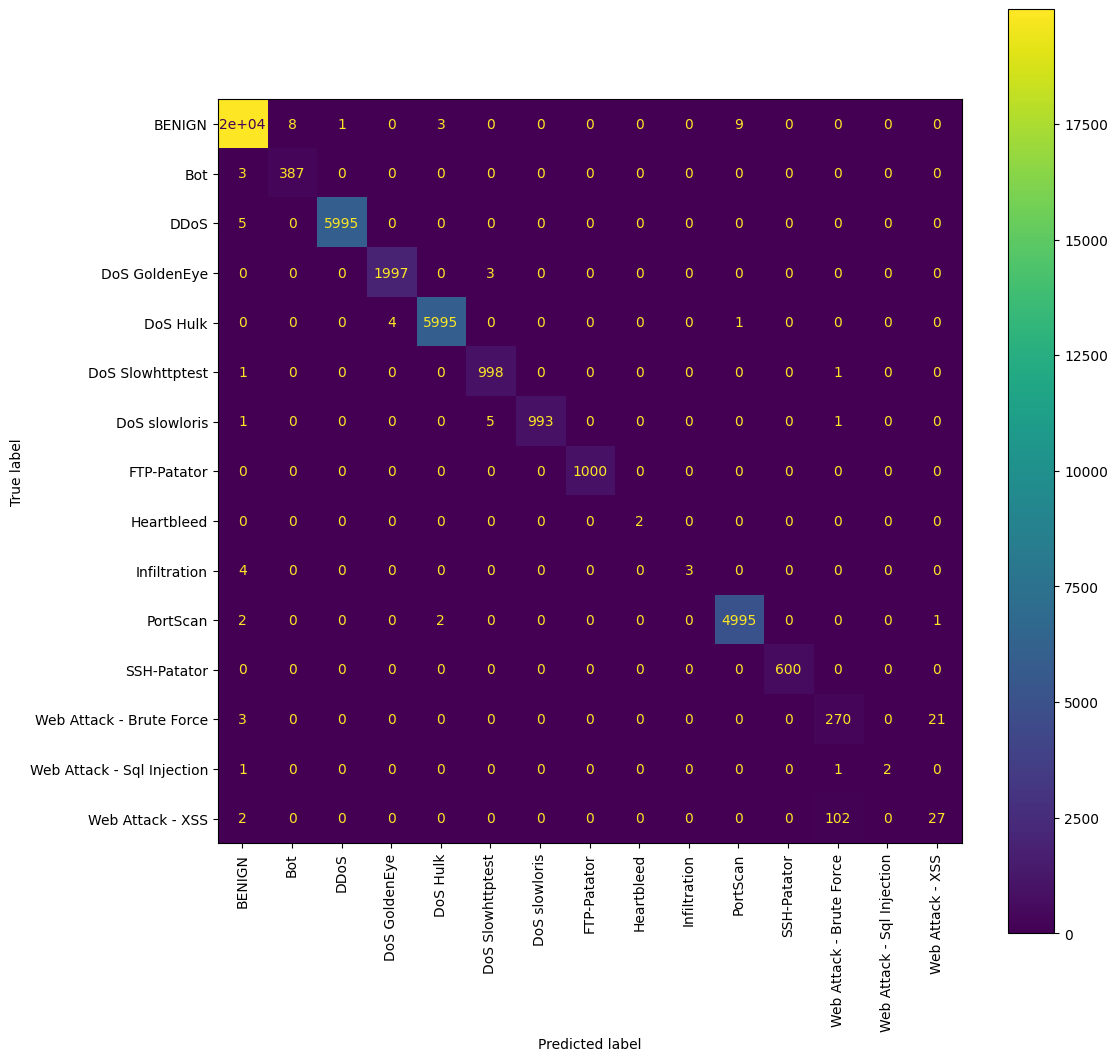

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=90)
plt.show()

In [29]:
joblib.dump(model, "../models/intrusion_model.pkl")
joblib.dump(X.columns.tolist(), "../models/feature_columns.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [30]:
import time
from pathlib import Path

import joblib
import mlflow
import mlflow.xgboost

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# MLflow Setup

mlruns_path = Path.cwd().parent / "mlruns"
mlruns_path.mkdir(exist_ok=True)

mlflow.set_tracking_uri(mlruns_path.resolve().as_uri())
mlflow.set_experiment("Network Intrusion Detection")

# Start MLflow Run


with mlflow.start_run():

    # Model
    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(label_encoder.classes_),
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )


    # Train Model
    start_train = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_train

    # -----------------------------
    # Prediction
    # -----------------------------
    start_pred = time.time()

    y_pred = model.predict(X_test)

    prediction_time = time.time() - start_pred

    # -----------------------------
    # Evaluation Metrics
    # -----------------------------
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("=" * 60)
    print(f"Training Time   : {train_time:.2f} sec")
    print(f"Prediction Time : {prediction_time:.4f} sec")
    print(f"Accuracy        : {accuracy:.4f}")
    print(f"Precision       : {precision:.4f}")
    print(f"Recall          : {recall:.4f}")
    print(f"F1 Score        : {f1:.4f}")
    print("=" * 60)

    print("\nClassification Report\n")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))

    print("\nConfusion Matrix\n")
    print(confusion_matrix(y_test, y_pred))

    # -----------------------------
    # Log Parameters
    # -----------------------------
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("objective", "multi:softprob")
    mlflow.log_param("num_classes", len(label_encoder.classes_))
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("tree_method", "hist")

    # -----------------------------
    # Log Metrics
    # -----------------------------
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("training_time_sec", train_time)
    mlflow.log_metric("prediction_time_sec", prediction_time)

    # -----------------------------
    # Save Artifacts
    # -----------------------------
    joblib.dump(model, "../models/intrusion_model.pkl")
    joblib.dump(label_encoder, "../models/label_encoder.pkl")
    joblib.dump(X.columns.tolist(), "../models/feature_columns.pkl")

    # -----------------------------
    # Log Model
    # -----------------------------
    mlflow.xgboost.log_model(
        xgb_model=model,
        name="network_intrusion_model"
    )

    # -----------------------------
    # Log Other Artifacts
    # -----------------------------
    mlflow.log_artifact("../models/label_encoder.pkl")
    mlflow.log_artifact("../models/feature_columns.pkl")

    print("\nModel Saved Successfully!")
    print("MLflow Run Logged Successfully!")

Training Time   : 17.38 sec
Prediction Time : 0.1345 sec
Accuracy        : 0.9957
Precision       : 0.9954
Recall          : 0.9957
F1 Score        : 0.9952

Classification Report

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00     20000
                       Bot       0.98      0.99      0.99       390
                      DDoS       1.00      1.00      1.00      6000
             DoS GoldenEye       1.00      1.00      1.00      2000
                  DoS Hulk       1.00      1.00      1.00      6000
          DoS Slowhttptest       0.99      1.00      1.00      1000
             DoS slowloris       1.00      0.99      1.00      1000
               FTP-Patator       1.00      1.00      1.00      1000
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.43      0.60         7
                  PortScan       1.00      1.00      1.00      5000
  

c:\Network Intrusion Detection System\.venv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [15:27:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2026/07/08 15:28:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Model Saved Successfully!
MLflow Run Logged Successfully!


In [31]:
import joblib

feature_columns = joblib.load("models/feature_columns.pkl")

print(feature_columns[:10])
print(len(feature_columns))

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']
78


In [32]:
from pydantic import BaseModel, Field

class NetworkFlow(BaseModel):
    Destination_Port: int = Field(alias="Destination Port")
    Flow_Duration: int = Field(alias="Flow Duration")
    Total_Fwd_Packets: int = Field(alias="Total Fwd Packets")
    ...